<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day12_practice2_YOLO_OCR_%EA%B2%B0%ED%95%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLO + OCR 결합

# 큰 사진 속 작은 번호판을 읽는 두 방법
#     방법 A: 사진 전체를 OCR    → 느리고, 노이즈가 섞인다
#     방법 B: 감지(YOLO)러 크롭  → OCR → 빠르고 정확하다

In [2]:
! pip install EasyOCR

In [3]:
import easyocr
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [4]:
# 셀 1. Reader 생성
reader = easyocr.Reader(["ko","en"], gpu=False, verbose=False) # OCR 엔진 객체 생성 (언어를 정하면 모델을 메모리에 로드)

In [5]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib          # 폰트 캐시 비우기

In [6]:
# 셀 2. OCR 시각화 도구 준비 - 원본 이미지 vs 판독 결과 이미지

import matplotlib.font_manager as fm

# Install Nanum Gothic font
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum > /dev/null

# Rebuild font caches (removed the problematic line)
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

# Find the font path after installation (optional, but good for robustness)
font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


def load_font(size=48):
    return ImageFont.truetype(font_path, size)

def draw_ocr_boxes(image_path, results, box_color="red", text_color="blue"):
  img = Image.open(image_path).convert("RGB")
  d = ImageDraw.Draw(img)
  font = load_font(48)

  for box, text, conf in results:
    points = [tuple(p) for p in box]
    d.line(points + [points[0]], fill=box_color, width=3)
    label = f"{text} ({conf:.2f})"
    label_pos = (points[0][0], max(points[0][1] - 26,0))
    d.text(label_pos, label, fill=text_color, font=font)
  return img

def show_original_and_result(image_path, results):
  result_img = draw_ocr_boxes(image_path, results)
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))
  axes[0].imshow(plt.imread(image_path))
  axes[0].set_title("원본 이미지")
  axes[0].axis("off")

  axes[1].imshow(result_img)
  axes[1].set_title("OCR  판독 결과")
  axes[1].axis("off")
  plt.show()



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [7]:
# 셀 1. 거리 장면 모사 이미지 - 번호판은 사진의 3%
scene_path = '/content/drive/MyDrive/kwu/DL/day12_sample_images/scene.jpg'

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import glob

files = glob.glob("/content/drive/MyDrive/**/scene.jpg", recursive=True)
print(files)

['/content/drive/MyDrive/kwu/DL/day12_sample_images/scene.jpg']



[방법 A: 전체 OCR] 32.7초
 읽힌 것 전부: ['서울', '12km', 'PIZZA STORE', 'Raw', 'PIZZA', 'PASTA', 'BEVERAGE', '서울 32가 4567', 'Roy']


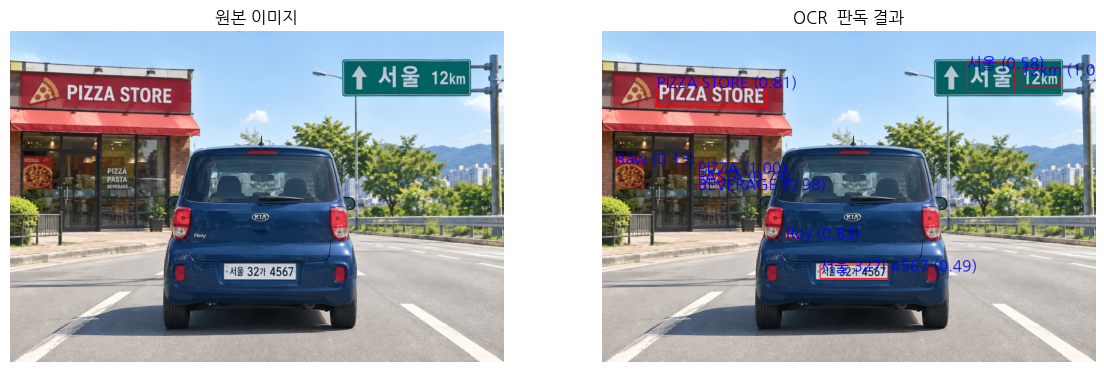

In [10]:
import time

# 셀 2. 방법 A - 사진 '전체'를 OCR

t0 = time.time()
results_a_full = reader.readtext(
    "/content/drive/MyDrive/kwu/DL/day12_sample_images/scene.jpg"
)

results_a = [text for box, text, conf in results_a_full]
time_a = time.time() - t0

print(f"\n[방법 A: 전체 OCR] {time_a:.1f}초")
print(" 읽힌 것 전부:", results_a)

show_original_and_result("/content/drive/MyDrive/kwu/DL/day12_sample_images/scene.jpg", results_a_full)

In [11]:
!pip install ultralytics -q


image 1/1 /content/drive/MyDrive/kwu/DL/day12_sample_images/scene.jpg: 288x416 2 plates, 124.0ms
Speed: 3.2ms preprocess, 124.0ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 416)
YOLO 감지 박스: (652, 715, 896, 782) (신뢰도 0.45)

[방법 B: 크롭 후 OCR] 1.4초
 읽힌 것: ['서울32가4567']


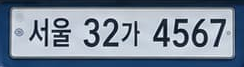

In [13]:
# 셀 3. 방법 B  - YOLO 감지(자르기) 후 OCR
from ultralytics import YOLO

# 한글 차량 번호판만 학습한 YOLO 모델을 허깅페이스에서 다운로드 받아서 사용
from huggingface_hub import hf_hub_download
model_path = hf_hub_download(
    repo_id="sauce-hug/korean-license-plate-detector",
    filename="plate_detect_v1/weights/best.pt"
)
plate_model = YOLO(model_path)
detections = plate_model(scene_path)

boxes = detections[0].boxes

if len(boxes) == 0:
  raise RuntimeError("YOLO가 번호판을 감지하지 못했습니다 - 모델 파일 또는 이미지를 확인하세요.")

# 사진에 차가 여러 대 찍혀 있어 박스가 여러 개 나올 때
# 신뢰도 (confidence)가 가장 높은 박스 하나를 '진짜 번호판'으로 선택
best_idx = boxes.conf.argmax().item() # conf  텐서에서 가장 큰 값의 인덱스
xyxy = boxes.xyxy[best_idx].tolist()
box = tuple(round(v) for v in xyxy)
print(f"YOLO 감지 박스: {box} (신뢰도 {boxes.conf[best_idx]:.2f})")

t0 = time.time()
plate = Image.open(scene_path).crop(box) # crop(x1,y1,x2,y2)로 박스만 잘라냄
plate.save("plate_crop.png") # 실제 사진에서 번호판 영역을 크롭한 이미지

results_b_full = reader.readtext("plate_crop.png", allowlist="가나다라마거너더러머버서어저고노도로모보소오조구누두루무부수우주아바사자하허호배서울경기인천대전대구부산광주울산세종강원충북충남전북전남경북경남제주0123456789")
results_b = [text for box, text, conf in results_b_full]
time_b = time.time() - t0

print(f"\n[방법 B: 크롭 후 OCR] {time_b:.1f}초")
print(" 읽힌 것:", results_b)
from IPython.display import display

plate.save("plate_crop.png")
display(plate)
